# Laboratorio #2 — Redes Neuronales Convolucionales (CNN)

**CC3092 · Deep Learning y Sistemas Inteligentes** — Universidad del Valle de Guatemala

**Autor:** Nicolás Concuá

Clasificación de dígitos manuscritos del dataset **MNIST** (0–9). Se construyen,
entrenan y comparan dos arquitecturas: un **MLP** (imagen aplanada) y una **CNN**
(imagen como tensor 2D con capas convolucionales).


## 0. Configuración del entorno

### 0.1 Instalación de dependencias

La siguiente celda instala las librerías necesarias si no están presentes (útil en
Colab o en un entorno nuevo). Si ya las tienes instaladas, puedes omitirla.

In [ ]:
# Descomenta la siguiente línea para instalar las dependencias (p. ej. en Colab o un entorno nuevo):
# !pip install torch torchvision numpy pandas matplotlib scikit-learn

### 0.2 Importaciones y configuración

Importamos las librerías, fijamos una semilla para reproducibilidad y seleccionamos
el dispositivo de cómputo (GPU Apple *MPS* si está disponible, si no CPU).

In [3]:
import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import MNIST
import torchvision.transforms as T

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# --- Reproducibilidad ---
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

# --- Dispositivo ---
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Dispositivo:", device)

# --- Rutas ---
DATA_DIR      = "../data"
REPORTS_DIR   = "../reports"
ARTIFACTS_DIR = "../reports/artifacts"   # histories + pesos cacheados (no se versiona)
for d in (DATA_DIR, REPORTS_DIR, ARTIFACTS_DIR):
    os.makedirs(d, exist_ok=True)

# Si CACHE=True, un experimento ya entrenado se recarga desde disco en vez de
# volver a entrenarse. Permite re-ejecutar el notebook rápidamente.
CACHE = True

Dispositivo: mps


## 1. Dataset

Trabajamos con **MNIST** (`torchvision.datasets.MNIST`): 70,000 imágenes en escala
de grises de dígitos manuscritos (0–9), divididas oficialmente en 60,000 de
entrenamiento y 10,000 de prueba (*test*).

## 2. Exploración y preparación de los datos

Primero cargamos el dataset **sin normalizar** (solo `ToTensor`, que escala los
píxeles de `[0, 255]` a `[0, 1]`) para responder las preguntas de exploración.

In [4]:
# Carga cruda para exploracion (ToTensor -> [0,1])
raw_train = MNIST(DATA_DIR, train=True,  download=True, transform=T.ToTensor())
raw_test  = MNIST(DATA_DIR, train=False, download=True, transform=T.ToTensor())

print("Imágenes de entrenamiento:", len(raw_train))
print("Imágenes de test:         ", len(raw_test))
print("Clases:                   ", raw_train.classes)
print("Nº de clases:             ", len(raw_train.classes))

Imágenes de entrenamiento: 60000
Imágenes de test:          10000
Clases:                    ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Nº de clases:              10


### 2.1 ¿Cuántas observaciones y clases? ¿Están balanceadas las clases?

,dígito,conteo,porcentaje
0,0,5923,9.87
1,1,6742,11.24
2,2,5958,9.93
3,3,6131,10.22
4,4,5842,9.74
5,5,5421,9.04
6,6,5918,9.86
7,7,6265,10.44
8,8,5851,9.75
9,9,5949,9.92


Mín: 5421  Máx: 6742  Desbalance máx/mín: 1.244


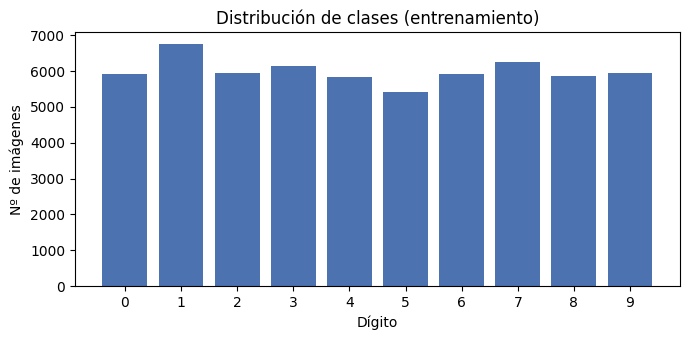

In [5]:
# Conteo de ejemplos por clase en entrenamiento
labels_train = raw_train.targets.numpy()
counts = np.bincount(labels_train, minlength=10)
dist = pd.DataFrame({"dígito": np.arange(10),
                     "conteo": counts,
                     "porcentaje": (counts / counts.sum() * 100).round(2)})
display(dist)
print(f"Mín: {counts.min()}  Máx: {counts.max()}  "
      f"Desbalance máx/mín: {counts.max()/counts.min():.3f}")

plt.figure(figsize=(7,3.5))
plt.bar(np.arange(10), counts, color="#4C72B0")
plt.xticks(np.arange(10)); plt.xlabel("Dígito"); plt.ylabel("Nº de imágenes")
plt.title("Distribución de clases (entrenamiento)")
plt.tight_layout(); plt.show()

**Respuesta.** El dataset tiene **60,000** imágenes de entrenamiento y **10,000**
de test, con **10 clases** (dígitos 0–9). Las clases están **razonablemente
balanceadas**: todas rondan entre ~5,400 y ~6,700 ejemplos (relación máx/mín ≈ 1.2),
por lo que no se requieren técnicas de balanceo.

### 2.2 Dimensión de cada imagen y rango de los píxeles

In [6]:
img, label = raw_train[0]
print("Shape de un ejemplo (C, H, W):", tuple(img.shape))
print("Tipo:", img.dtype)
print("Rango tras ToTensor: min =", img.min().item(), " max =", img.max().item())

# Rango original (0-255) directamente del tensor de datos crudos
print("Rango de píxeles original (uint8):",
      raw_train.data.min().item(), "-", raw_train.data.max().item())

Shape de un ejemplo (C, H, W): (1, 28, 28)
Tipo: torch.float32
Rango tras ToTensor: min = 0.0  max = 1.0
Rango de píxeles original (uint8): 0 - 255


**Respuesta.** Cada imagen es de **28×28 píxeles en 1 canal** (escala de grises),
es decir un tensor `(1, 28, 28)`. Los píxeles originales están en `[0, 255]`
(enteros `uint8`); tras `ToTensor` quedan en `[0.0, 1.0]`.

### 2.3 ¿Es necesario normalizar los valores de los píxeles?

In [7]:
# Media y desviacion estandar del conjunto de entrenamiento (sobre [0,1])
mean = (raw_train.data.float() / 255.0).mean().item()
std  = (raw_train.data.float() / 255.0).std().item()
print(f"Media = {mean:.4f}   Std = {std:.4f}")

Media = 0.1307   Std = 0.3081


**Respuesta.** Sí conviene normalizar. Aunque `ToTensor` ya reescala a `[0, 1]`,
**estandarizar** (restar la media y dividir por la desviación estándar) centra los
datos en torno a 0 con varianza ~1. Esto mejora el condicionamiento del problema de
optimización: los gradientes quedan mejor escalados y el entrenamiento converge más
rápido y de forma más estable. Usaremos los valores canónicos de MNIST
**media = 0.1307** y **std = 0.3081** (equivalentes a los calculados arriba).

### 2.4 Visualización de ejemplos

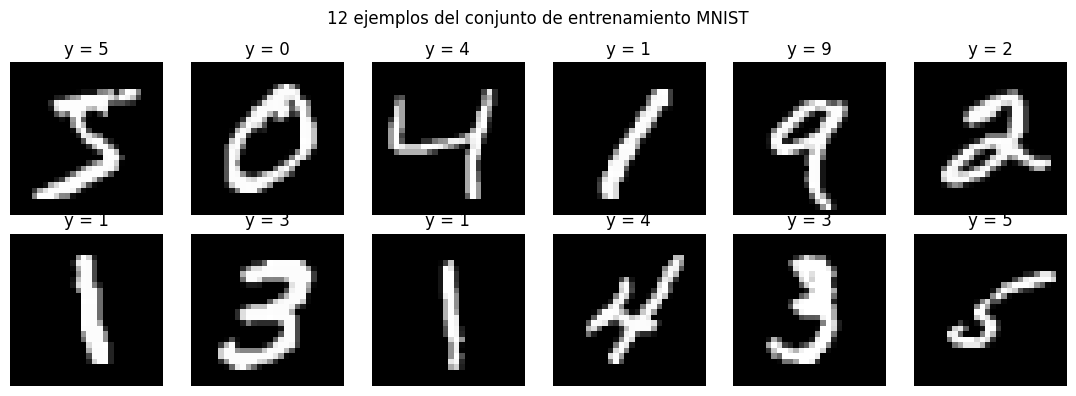

In [8]:
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for i, ax in enumerate(axes.flat):
    img, label = raw_train[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"y = {label}"); ax.axis("off")
plt.suptitle("12 ejemplos del conjunto de entrenamiento MNIST")
plt.tight_layout(); plt.show()

### 2.5 Preparación: normalización y división train / validación

Definimos la transformación final con **estandarización** y dividimos las 60,000
imágenes de entrenamiento en **54,000 para entrenamiento** y **6,000 para
validación** (90/10) con una semilla fija. El conjunto de **test (10,000)** se
mantiene aparte y solo se usará una vez al final.

In [9]:
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081
transform = T.Compose([T.ToTensor(), T.Normalize((MNIST_MEAN,), (MNIST_STD,))])

full_train = MNIST(DATA_DIR, train=True,  download=True, transform=transform)
test_set   = MNIST(DATA_DIR, train=False, download=True, transform=transform)

n_val = 6000
n_train = len(full_train) - n_val
train_set, val_set = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED))

print(f"Train: {len(train_set)}  |  Val: {len(val_set)}  |  Test: {len(test_set)}")

Train: 54000  |  Val: 6000  |  Test: 10000


## 3. Investigación: capas de PyTorch para la CNN

Descripción del propósito y los parámetros más relevantes de cada capa de
`torch.nn` utilizada en la CNN.

### `nn.Conv2d`
Aplica una **convolución 2D**: desliza filtros (*kernels*) aprendibles sobre la
imagen para extraer características locales (bordes, texturas, formas). Cada filtro
produce un *feature map*.
- `in_channels` / `out_channels`: canales de entrada y número de filtros (= canales de salida).
- `kernel_size`: tamaño de la ventana del filtro (p. ej. 3×3).
- `stride`: paso del desplazamiento (por defecto 1).
- `padding`: relleno de ceros en los bordes; con `padding=1` y kernel 3×3 se conserva el tamaño espacial.

### `nn.MaxPool2d`
**Submuestreo por máximo**: divide el mapa en ventanas y conserva el valor máximo de
cada una. Reduce la resolución espacial (y el cómputo), aporta cierta invariancia a
pequeñas traslaciones y amplía el campo receptivo.
- `kernel_size`: tamaño de la ventana (p. ej. 2 → reduce a la mitad).
- `stride`: paso (por defecto igual a `kernel_size`).

### `nn.AvgPool2d`
Igual que `MaxPool2d` pero conserva el **promedio** de cada ventana en lugar del
máximo. Suaviza la representación; se usa a veces (como *global average pooling*)
antes del clasificador. Mismos parámetros principales (`kernel_size`, `stride`).

### `nn.BatchNorm2d`
**Normalización por lotes** sobre mapas 2D: normaliza cada canal usando la media y
varianza del *batch*, y aplica un escalado (`γ`) y desplazamiento (`β`) aprendibles.
Estabiliza y acelera el entrenamiento, permite tasas de aprendizaje mayores y actúa
como leve regularizador.
- `num_features`: número de canales de entrada (debe coincidir con los del `Conv2d` previo).

### `nn.Flatten`
**Aplana** un tensor multidimensional a un vector (conservando la dimensión del
*batch*). Sirve de puente entre las capas convolucionales `(N, C, H, W)` y las capas
densas `(N, C·H·W)`. Parámetros: `start_dim` (por defecto 1) y `end_dim`.

### `nn.CrossEntropyLoss`
Función de **pérdida** para clasificación multiclase. Combina internamente
`LogSoftmax` + `NLLLoss`, por lo que **recibe los *logits* crudos** (sin aplicar
softmax) y las etiquetas como índices de clase enteros. Penaliza la divergencia
entre la distribución predicha y la clase verdadera.
- `weight`: pesos por clase (útil ante desbalance).
- `label_smoothing`: suavizado de etiquetas para regularizar.

---

### Conceptos adicionales

**Tensor.** Estructura de datos central de PyTorch: un arreglo n-dimensional
(generalización de escalares, vectores y matrices) que soporta cómputo en
GPU/MPS y **diferenciación automática** (autograd). Las imágenes se representan como
tensores `(N, C, H, W)`.

**Campo receptivo (*receptive field*).** Región de la imagen de entrada que influye
en el cálculo de una neurona/píxel de una capa dada. En las primeras capas es
pequeño (detecta detalles locales) y crece con la profundidad y el *pooling*,
permitiendo que las capas profundas capten patrones cada vez más globales.

**¿Por qué una CNN usa menos parámetros que un MLP equivalente?** Por dos
propiedades: (1) **conectividad local** — cada neurona convolucional se conecta solo
a una pequeña región, no a todos los píxeles; y (2) **compartición de pesos** — el
mismo filtro se reutiliza en toda la imagen. Un filtro 3×3 tiene solo ~9 pesos por
canal y se aplica en todas las posiciones, mientras que una capa densa sobre una
imagen 28×28 requiere 784 pesos **por cada** neurona. Así la CNN captura estructura
espacial con una fracción de los parámetros.

## 4. Construcción y entrenamiento de las arquitecturas

Definimos ambas arquitecturas de forma **parametrizable** para poder iterar sobre
sus hiperparámetros, junto con las utilidades de entrenamiento y evaluación.

### 4.1 Definición de los modelos

In [10]:
class MLP(nn.Module):
    """MLP configurable que recibe la imagen aplanada (784) como vector."""
    def __init__(self, hidden=(256, 128), dropout=0.0, in_dim=28*28, n_classes=10):
        super().__init__()
        layers = [nn.Flatten()]
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class CNN(nn.Module):
    """CNN configurable: bloques Conv->[BN]->ReLU->MaxPool y clasificador denso."""
    def __init__(self, channels=(32, 64), use_bn=True, dropout=0.0, n_classes=10):
        super().__init__()
        blocks, in_c = [], 1
        for c in channels:
            blocks.append(nn.Conv2d(in_c, c, kernel_size=3, padding=1))
            if use_bn:
                blocks.append(nn.BatchNorm2d(c))
            blocks += [nn.ReLU(), nn.MaxPool2d(2)]
            in_c = c
        self.features = nn.Sequential(*blocks)
        spatial = 28 // (2 ** len(channels))          # tamaño espacial tras el pooling
        flat = in_c * spatial * spatial
        head = [nn.Flatten()]
        if dropout > 0:
            head.append(nn.Dropout(dropout))
        head.append(nn.Linear(flat, n_classes))
        self.classifier = nn.Sequential(*head)

    def forward(self, x):
        return self.classifier(self.features(x))


def count_params(model):
    """Nº de parámetros entrenables."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### 4.2 Utilidades de entrenamiento y evaluación

In [11]:
@torch.no_grad()
def evaluate(model, loader):
    """Devuelve (loss_promedio, y_true, y_pred) sobre un DataLoader."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, n = 0.0, 0
    y_true, y_pred = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * xb.size(0)
        n += xb.size(0)
        y_pred.append(logits.argmax(1).cpu())
        y_true.append(yb.cpu())
    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()
    return total_loss / n, y_true, y_pred


def metrics_dict(y_true, y_pred, average="macro"):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall":    recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1":        f1_score(y_true, y_pred, average=average, zero_division=0),
    }


def train_model(model, cfg, train_loader, val_loader):
    """Entrena y devuelve el historial. Selecciona el mejor epoch por F1 de validación
    y guarda esos pesos. Registra loss de train/val por epoch, métricas y tiempo."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"],
                                 weight_decay=cfg.get("weight_decay", 0.0))
    hist = {"train_loss": [], "val_loss": []}
    best_f1, best_state, best_metrics, best_epoch = -1.0, None, None, -1
    t0 = time.time()
    for epoch in range(cfg["epochs"]):
        model.train()
        run_loss, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * xb.size(0); n += xb.size(0)
        train_loss = run_loss / n
        val_loss, yt, yp = evaluate(model, val_loader)
        m = metrics_dict(yt, yp)
        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)
        if m["f1"] > best_f1:
            best_f1, best_metrics, best_epoch = m["f1"], m, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    elapsed = time.time() - t0
    hist.update({"config": cfg, "params": count_params(model),
                 "val_metrics": best_metrics, "best_epoch": best_epoch,
                 "train_time_s": elapsed})
    return hist, best_state


def run_experiment(name, build_fn, cfg, train_loader, val_loader):
    """Ejecuta (o recarga desde caché) un experimento y devuelve su historial."""
    hp = os.path.join(ARTIFACTS_DIR, f"{name}.json")
    wp = os.path.join(ARTIFACTS_DIR, f"{name}.pt")
    if CACHE and os.path.exists(hp) and os.path.exists(wp):
        with open(hp) as f:
            hist = json.load(f)
        print(f"[cache] {name}: F1_val={hist['val_metrics']['f1']:.4f}  "
              f"params={hist['params']:,}")
        return hist
    set_seed()                                   # misma inicializacion para todos
    model = build_fn()
    hist, best_state = train_model(model, cfg, train_loader, val_loader)
    torch.save(best_state, wp)
    with open(hp, "w") as f:
        json.dump(hist, f)
    print(f"[train] {name}: F1_val={hist['val_metrics']['f1']:.4f}  "
          f"params={hist['params']:,}  time={hist['train_time_s']:.1f}s")
    return hist

### 4.3 Estrategia de búsqueda de hiperparámetros

Realizamos **6 iteraciones por arquitectura (12 en total)**, cambiando **una o dos
variables a la vez** para poder atribuir el efecto de cada cambio. Los `DataLoader`
usan un *batch size* fijo de 128 y todos los modelos se entrenan con Adam durante 10
epochs, de modo que las diferencias observadas se deban a los hiperparámetros
estudiados (ancho/profundidad, regularización por *dropout* y *weight decay*, tasa
de aprendizaje y uso de *BatchNorm*).

In [12]:
BATCH = 128
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)
EPOCHS = 10

# --- 6 configuraciones de MLP (se varia 1-2 cosas a la vez) ---
mlp_configs = [
    ("MLP-1_base",         dict(hidden=(128,),      dropout=0.0), dict(lr=1e-3, weight_decay=0.0)),
    ("MLP-2_wider",        dict(hidden=(256,),      dropout=0.0), dict(lr=1e-3, weight_decay=0.0)),
    ("MLP-3_deeper",       dict(hidden=(256,128),   dropout=0.0), dict(lr=1e-3, weight_decay=0.0)),
    ("MLP-4_dropout",      dict(hidden=(256,128),   dropout=0.3), dict(lr=1e-3, weight_decay=0.0)),
    ("MLP-5_dropout_wd",   dict(hidden=(256,128),   dropout=0.3), dict(lr=1e-3, weight_decay=1e-4)),
    ("MLP-6_bigger_reg",   dict(hidden=(512,256),   dropout=0.3), dict(lr=1e-3, weight_decay=1e-4)),
]

# --- 6 configuraciones de CNN ---
cnn_configs = [
    ("CNN-1_base",         dict(channels=(16,32),   use_bn=False, dropout=0.0), dict(lr=1e-3, weight_decay=0.0)),
    ("CNN-2_wider",        dict(channels=(32,64),   use_bn=False, dropout=0.0), dict(lr=1e-3, weight_decay=0.0)),
    ("CNN-3_batchnorm",    dict(channels=(32,64),   use_bn=True,  dropout=0.0), dict(lr=1e-3, weight_decay=0.0)),
    ("CNN-4_bn_dropout",   dict(channels=(32,64),   use_bn=True,  dropout=0.25),dict(lr=1e-3, weight_decay=0.0)),
    ("CNN-5_bn_drop_wd",   dict(channels=(32,64),   use_bn=True,  dropout=0.25),dict(lr=1e-3, weight_decay=1e-4)),
    ("CNN-6_deeper",       dict(channels=(32,64,128),use_bn=True, dropout=0.25),dict(lr=1e-3, weight_decay=1e-4)),
]

In [13]:
results = {}   # name -> hist

for name, march, mopt in mlp_configs:
    cfg = dict(**mopt, epochs=EPOCHS, arch="MLP", **march)
    results[name] = run_experiment(name, lambda a=march: MLP(**a), cfg,
                                   train_loader, val_loader)

for name, carch, copt in cnn_configs:
    cfg = dict(**copt, epochs=EPOCHS, arch="CNN", **carch)
    results[name] = run_experiment(name, lambda a=carch: CNN(**a), cfg,
                                   train_loader, val_loader)

print("\nTotal de experimentos:", len(results))

[cache] MLP-1_base: F1_val=0.9744  params=101,770
[cache] MLP-2_wider: F1_val=0.9771  params=203,530
[cache] MLP-3_deeper: F1_val=0.9761  params=235,146
[cache] MLP-4_dropout: F1_val=0.9785  params=235,146
[cache] MLP-5_dropout_wd: F1_val=0.9781  params=235,146
[cache] MLP-6_bigger_reg: F1_val=0.9794  params=535,818
[cache] CNN-1_base: F1_val=0.9864  params=20,490
[cache] CNN-2_wider: F1_val=0.9874  params=50,186
[cache] CNN-3_batchnorm: F1_val=0.9875  params=50,378
[cache] CNN-4_bn_dropout: F1_val=0.9902  params=50,378
[cache] CNN-5_bn_drop_wd: F1_val=0.9885  params=50,378
[cache] CNN-6_deeper: F1_val=0.9917  params=104,650

Total de experimentos: 12


### 4.4 Tabla de resultados de las iteraciones

In [14]:
rows = []
for name, h in results.items():
    c, m = h["config"], h["val_metrics"]
    rows.append({
        "iteración": name,
        "arch": c["arch"],
        "config": (f"hidden={c.get('hidden')}" if c["arch"]=="MLP"
                   else f"ch={c.get('channels')}, bn={c.get('use_bn')}"),
        "dropout": c.get("dropout", 0.0),
        "wd": c.get("weight_decay", 0.0),
        "lr": c["lr"],
        "params": h["params"],
        "val_acc":  round(m["accuracy"], 4),
        "val_prec": round(m["precision"], 4),
        "val_rec":  round(m["recall"], 4),
        "val_f1":   round(m["f1"], 4),
        "tiempo_s": round(h["train_time_s"], 1),
    })
results_df = pd.DataFrame(rows)
display(results_df)

,iteración,arch,config,dropout,wd,lr,params,val_acc,val_prec,val_rec,val_f1,tiempo_s
0,MLP-1_base,MLP,hidden=[128],0.00,0.0000,0.001,101770,0.9747,0.9744,0.9744,0.9744,24.6
1,MLP-2_wider,MLP,hidden=[256],0.00,0.0000,0.001,203530,0.9773,0.9772,0.9770,0.9771,21.8
2,MLP-3_deeper,MLP,"hidden=[256, 128]",0.00,0.0000,0.001,235146,0.9763,0.9760,0.9763,0.9761,22.7
3,MLP-4_dropout,MLP,"hidden=[256, 128]",0.30,0.0000,0.001,235146,0.9788,0.9786,0.9786,0.9785,23.3
4,MLP-5_dropout_wd,MLP,"hidden=[256, 128]",0.30,0.0001,0.001,235146,0.9785,0.9782,0.9781,0.9781,24.5
5,MLP-6_bigger_reg,MLP,"hidden=[512, 256]",0.30,0.0001,0.001,535818,0.9797,0.9795,0.9794,0.9794,26.4
6,CNN-1_base,CNN,"ch=[16, 32], bn=False",0.00,0.0000,0.001,20490,0.9865,0.9865,0.9863,0.9864,34.0
7,CNN-2_wider,CNN,"ch=[32, 64], bn=False",0.00,0.0000,0.001,50186,0.9875,0.9875,0.9873,0.9874,34.6
8,CNN-3_batchnorm,CNN,"ch=[32, 64], bn=True",0.00,0.0000,0.001,50378,0.9877,0.9876,0.9875,0.9875,38.2
9,CNN-4_bn_dropout,CNN,"ch=[32, 64], bn=True",0.25,0.0000,0.001,50378,0.9903,0.9902,0.9902,0.9902,36.5


### 4.5 Curvas de pérdida (train vs. validación)

Graficamos las curvas de al menos 3 iteraciones por arquitectura para identificar
visualmente señales de *overfitting* (la pérdida de validación sube mientras la de
entrenamiento baja) o *underfitting* (ambas pérdidas se estancan altas).

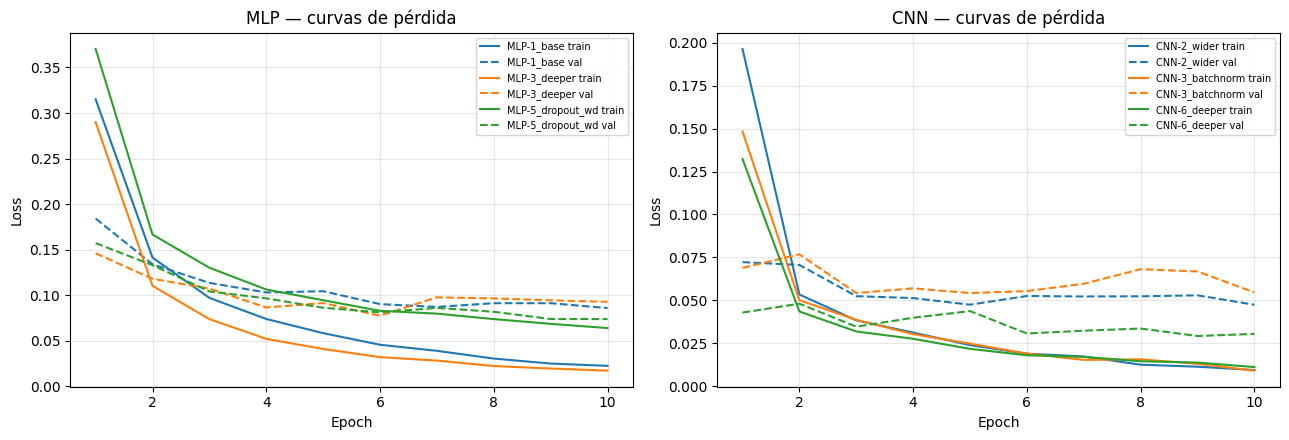

In [15]:
def plot_curves(names, title, ax):
    for nm in names:
        h = results[nm]
        ep = range(1, len(h["train_loss"]) + 1)
        line = ax.plot(ep, h["train_loss"], "-",  label=f"{nm} train")[0]
        ax.plot(ep, h["val_loss"], "--", color=line.get_color(), label=f"{nm} val")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
plot_curves(["MLP-1_base", "MLP-3_deeper", "MLP-5_dropout_wd"],
            "MLP — curvas de pérdida", ax1)
plot_curves(["CNN-2_wider", "CNN-3_batchnorm", "CNN-6_deeper"],
            "CNN — curvas de pérdida", ax2)
plt.tight_layout(); plt.show()